# Example-24: Autocorrelation

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

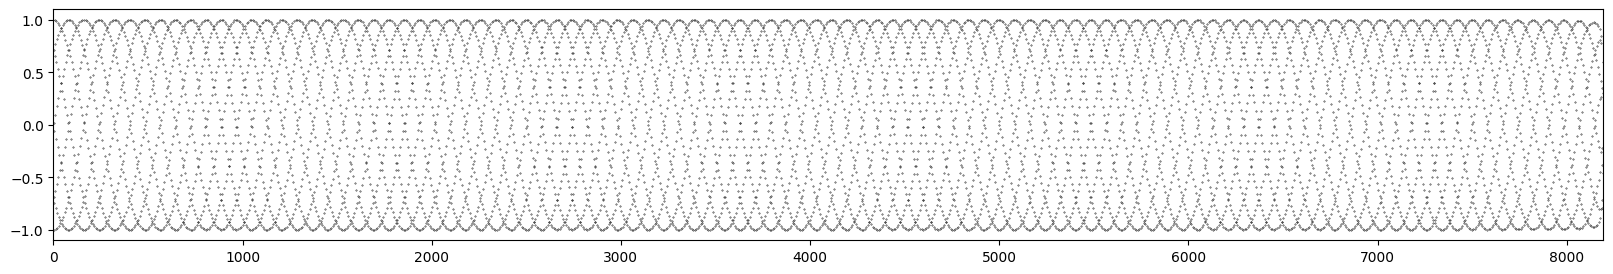

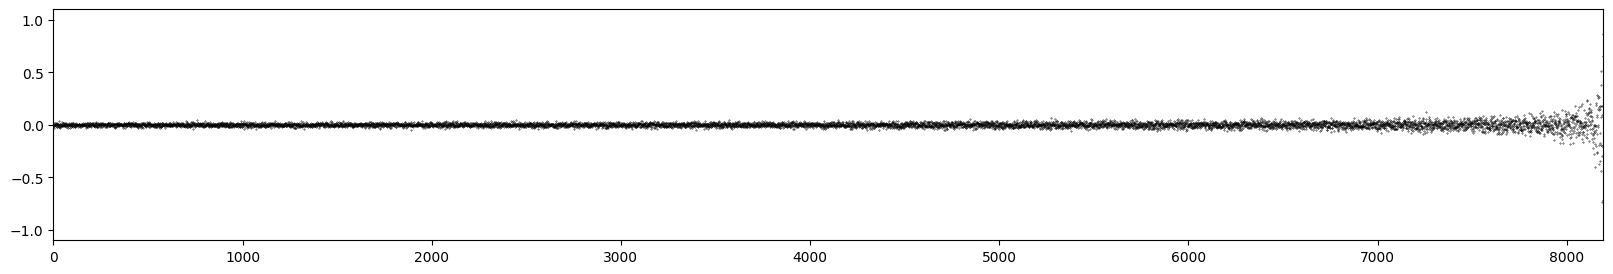

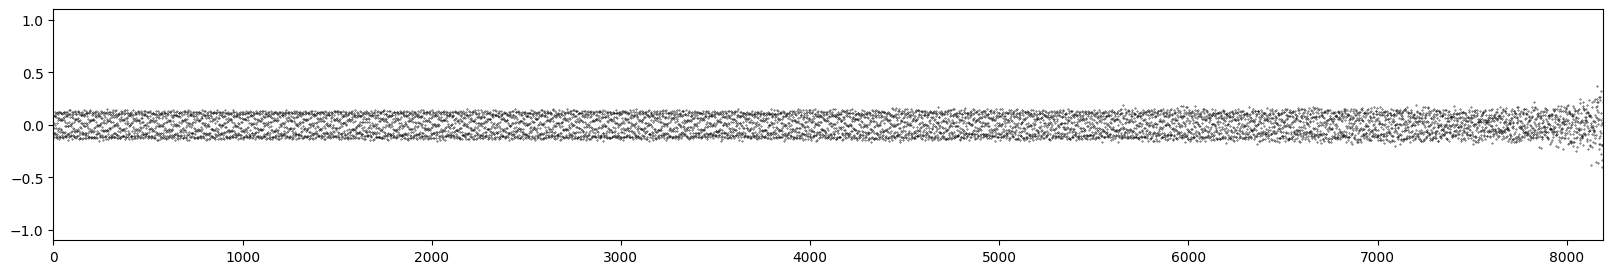

In [3]:
# Compute autocorrelation for harmonic, random noise and 'hidden' harmonic with noise

length = 8192

s = torch.cos(2.0*numpy.pi*0.12345*torch.linspace(1, length, length, dtype=dtype, device=device)).unsqueeze(0)
auto1 = Frequency.autocorrelation(s)
plt.figure(figsize=(20, 3))
plt.scatter(range(length), auto1[0].cpu().numpy(), c='black', s=0.1)
plt.xlim(0, length + 1)
plt.ylim(-1.1, 1.1)
plt.show()

s = torch.randn((1, length), dtype=dtype, device=device)
auto2 = Frequency.autocorrelation(s)
plt.figure(figsize=(20, 3))
plt.scatter(range(length), auto2[0].cpu().numpy(), c='black', s=0.1)
plt.xlim(0, length + 1)
plt.ylim(-1.1, 1.1)
plt.show()

s = 0.5*torch.cos(2.0*numpy.pi*0.12345*torch.linspace(1, length, length, dtype=dtype, device=device)).unsqueeze(0)
s += torch.randn((1, length), dtype=dtype, device=device)
auto3 = Frequency.autocorrelation(s)
plt.figure(figsize=(20, 3))
plt.scatter(range(length), auto3[0].cpu().numpy(), c='black', s=0.1)
plt.xlim(0, length + 1)
plt.ylim(-1.1, 1.1)
plt.show()

[0.12345006 0.3551221  0.12345072]


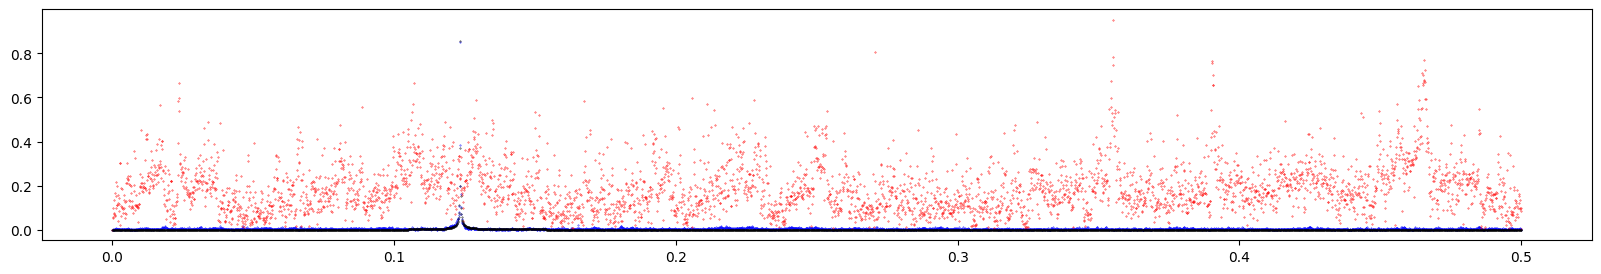

In [4]:
# Examine autocorrelation spectrum

w = Window.from_cosine(length, 0.0, dtype=dtype, device=device)
d = Data.from_data(w, torch.cat([auto1, auto2, auto3]))
d.window_remove_mean()
d.window_apply()
f = Frequency(d)
f('parabola')
print(f.frequency.cpu().numpy())

plt.figure(figsize=(20, 3))
plt.scatter(f.fft_grid.cpu().numpy(), (f.fft_spectrum[2]/f.ffrft_spectrum[2].max()).cpu().numpy(), color='blue', s=0.1)
plt.scatter(f.fft_grid.cpu().numpy(), (f.fft_spectrum[1]/f.ffrft_spectrum[1].max()).cpu().numpy(), color='red', s=0.1)
plt.scatter(f.fft_grid.cpu().numpy(), (f.fft_spectrum[0]/f.ffrft_spectrum[0].max()).cpu().numpy(), color='black', s=0.1)
plt.show()